In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [7]:
import os
os.chdir(r"C:\Users\Megha Poojary\IdeaProjects\ML")

print(os.getcwd())

C:\Users\Megha Poojary\IdeaProjects\ML


# Final merged dataset

In [8]:
df=pd.read_csv('Data/final_merged_data.csv')

In [9]:
df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Dept,Weekly_Sales,Type,Size
0,1,2010-02-05,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,False,1,24924.50,A,151315
1,1,2010-02-05,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,False,2,50605.27,A,151315
2,1,2010-02-05,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,False,3,13740.12,A,151315
3,1,2010-02-05,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,False,4,39954.04,A,151315
4,1,2010-02-05,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,False,5,32229.38,A,151315


### EDA overview
1. data overview
2. Sales performance analysis
3. Weekly, monthly, etc sales trend
4. Holiday analysis
5. Store Analysis
6. Department analysis
7. external factors
8. Markdown analysis
9. Correlation analysis
10. Distribution analysis
11. Outlier analysis
12. Business Insights

### Data overview

In [10]:
df.shape

(420285, 16)

In [11]:
df.dtypes

Store             int64
Date             object
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
Dept              int64
Weekly_Sales    float64
Type             object
Size              int64
dtype: object

In [12]:
df.rename(columns={'IsHoliday': 'Holiday'}, inplace=True)

In [13]:
df.columns

Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Holiday',
       'Dept', 'Weekly_Sales', 'Type', 'Size'],
      dtype='object')

In [14]:
df['Date']=pd.to_datetime(df['Date'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420285 entries, 0 to 420284
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         420285 non-null  int64         
 1   Date          420285 non-null  datetime64[ns]
 2   Temperature   420285 non-null  float64       
 3   Fuel_Price    420285 non-null  float64       
 4   MarkDown1     420285 non-null  float64       
 5   MarkDown2     420285 non-null  float64       
 6   MarkDown3     420285 non-null  float64       
 7   MarkDown4     420285 non-null  float64       
 8   MarkDown5     420285 non-null  float64       
 9   CPI           420285 non-null  float64       
 10  Unemployment  420285 non-null  float64       
 11  Holiday       420285 non-null  bool          
 12  Dept          420285 non-null  int64         
 13  Weekly_Sales  420285 non-null  float64       
 14  Type          420285 non-null  object        
 15  Size          420

In [16]:
df.describe()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Dept,Weekly_Sales,Size
count,420285.000000,420285,420285.000000,420285.000000,420285.000000,420285.000000,420285.000000,420285.000000,420285.000000,420285.000000,420285.000000,420285.000000,420285.000000,420285.000000
mean,22.195477,2011-06-18 07:22:30.395088896,60.090474,3.360888,2590.187246,878.803239,468.771234,1083.462694,1662.706138,171.212152,7.960077,44.242771,16030.329773,136749.569176
min,1.000000,2010-02-05 00:00:00,-2.060000,2.472000,0.000000,-265.760000,-29.100000,0.000000,0.000000,126.064000,3.879000,1.000000,0.000000,34875.000000
25%,11.000000,2010-10-08 00:00:00,46.680000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,132.022667,6.891000,18.000000,2117.560000,93638.000000
50%,22.000000,2011-06-17 00:00:00,62.090000,3.452000,0.000000,0.000000,0.000000,0.000000,0.000000,182.350989,7.866000,37.000000,7659.090000,140167.000000
75%,33.000000,2012-02-24 00:00:00,74.280000,3.738000,2801.500000,2.400000,4.540000,425.290000,2168.040000,212.445487,8.567000,74.000000,20268.380000,202505.000000
max,45.000000,2012-10-26 00:00:00,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,99.000000,693099.360000,219622.000000
std,12.787213,NaN,18.448260,0.458523,6053.225499,5076.525234,5533.593113,3895.801513,4205.946641,39.162280,1.863873,30.507197,22728.500149,60992.688568


In [17]:
#Sales performance analysis
df['Weekly_Sales'].describe().round()

count    420285.0
mean      16030.0
std       22729.0
min           0.0
25%        2118.0
50%        7659.0
75%       20268.0
max      693099.0
Name: Weekly_Sales, dtype: float64

### Interpretation
- there are 420285.0 weekly sales in dataset
- the average weekly sales is 16030.0
- 22729.0 is the sd, meaning sales vary a lot across stores
- Min sales is 0, probably the stores were closed for the week
- 25% of the data have weekly sales below 2118.0
- 50% of the data, which is also the median, have weekly sales below 7659.0
- 75% of the data have weekly sales below 20268.0
- the highest recorded weekly sales is 693099.0

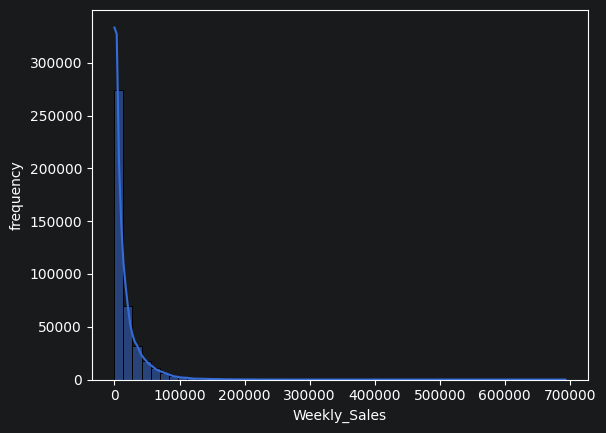

In [18]:
sns.histplot(df['Weekly_Sales'], kde=True, bins=50,)
plt.ylabel('frequency')
plt.show()

In [19]:
# the histogram is positively skewed, meaning
# some stores/depts have exceptionally large sales observations 

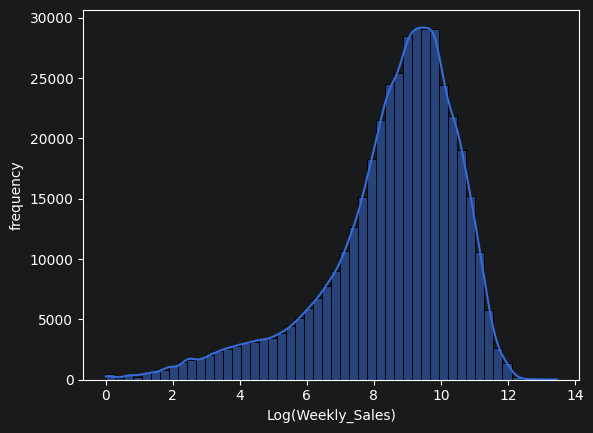

In [20]:
sns.histplot(np.log1p(df['Weekly_Sales']), kde=True, bins=50,)
plt.ylabel('frequency')
plt.xlabel("Log(Weekly_Sales)")
plt.show()

### Store performance

In [21]:
df.columns

Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Holiday',
       'Dept', 'Weekly_Sales', 'Type', 'Size'],
      dtype='object')

In [22]:
# Top 10 stores by sales
Top_10_stores=df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
Top_10_stores.head(10)

Store
20    3.014014e+08
4     2.995453e+08
14    2.890019e+08
13    2.865180e+08
2     2.753872e+08
10    2.716241e+08
27    2.538572e+08
6     2.237586e+08
1     2.224068e+08
39    2.074465e+08
Name: Weekly_Sales, dtype: float64

In [23]:
pd.options.display.float_format='{:,.0f}'.format

In [24]:
# Bottom 10 stores by sales
Bottom_10_stores=df.groupby('Store')['Weekly_Sales'].sum().round(0).sort_values(ascending=True)
Bottom_10_stores.head(10)

Store
33   37,160,325
44   43,293,672
5    45,476,120
36   53,413,353
38   55,159,901
3    57,587,926
30   62,717,012
37   74,202,861
16   74,256,735
29   77,142,827
Name: Weekly_Sales, dtype: float64

In [25]:
# Storewise average weekly sales
Storewise_avg_weekly_sales=df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False).reset_index()
Storewise_avg_weekly_sales.rename(columns={'Weekly_Sales': 'Mean_Weekly_Sales'}, inplace=True)
Storewise_avg_weekly_sales.head()

,Store,Mean_Weekly_Sales
0,20,"29,619"
1,4,"29,176"
2,14,"28,877"
3,13,"27,394"
4,2,"26,956"


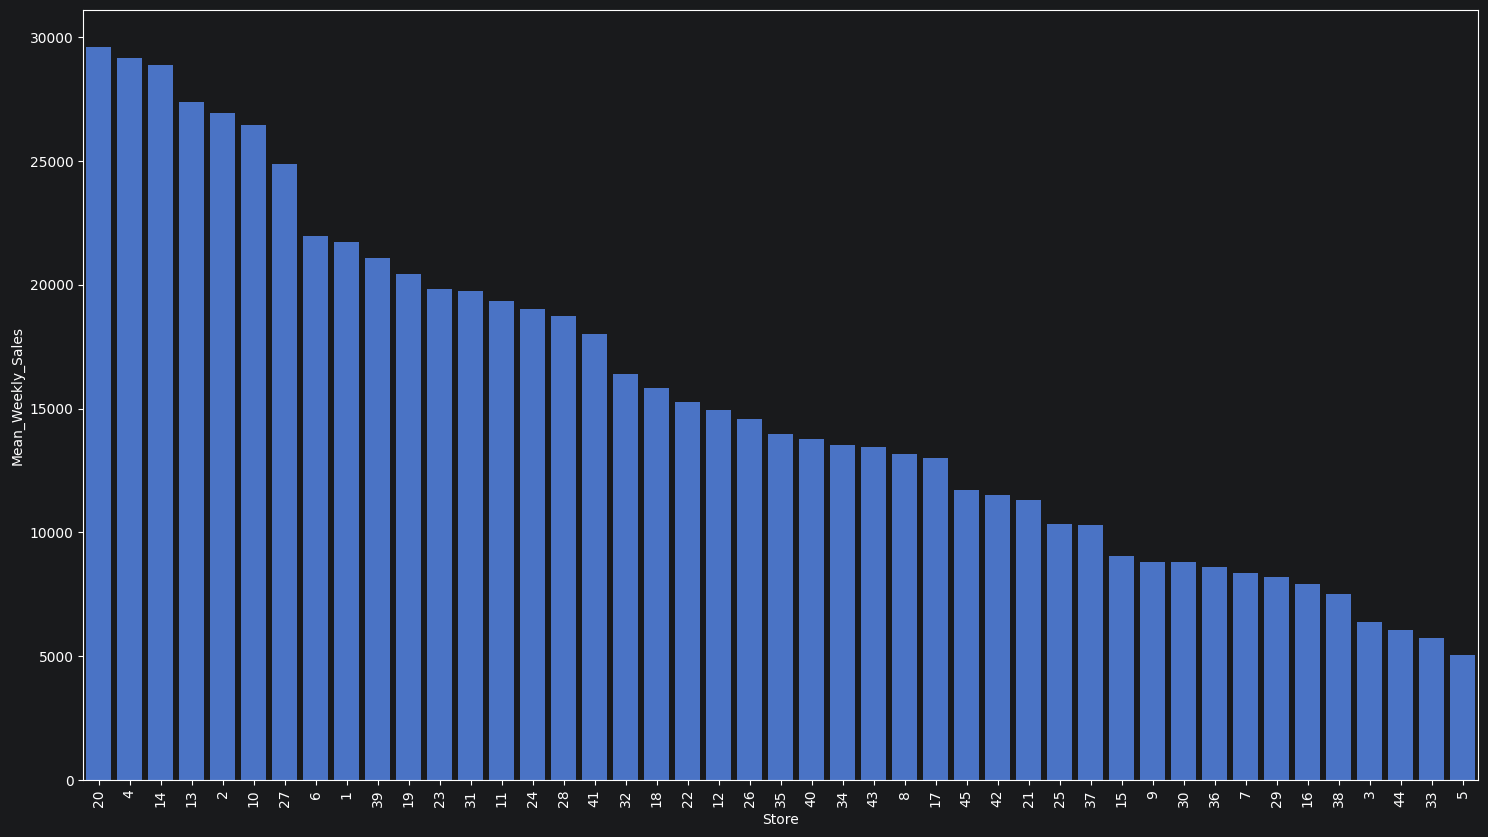

In [26]:
plt.figure(figsize=(18,10))
sns.barplot(data=Storewise_avg_weekly_sales, x='Store', y='Mean_Weekly_Sales', order=Storewise_avg_weekly_sales['Store'] )
plt.xlabel('Store')
plt.ylabel('Mean_Weekly_Sales')
plt.xticks(rotation=90)
plt.show()

In [27]:
# Store-wise sales variability (standard deviation)
Store_wise_SD=df.groupby('Store')['Weekly_Sales'].std().round().sort_values(ascending=False).reset_index()
Store_wise_SD.rename(columns={'Weekly_Sales': 'SD_Weekly_Sales'}, inplace=True)
Store_wise_SD.head()

,Store,SD_Weekly_Sales
0,14,"36,934"
1,20,"35,682"
2,4,"34,586"
3,13,"33,862"
4,2,"33,089"


In [28]:
Store_stats=pd.merge(Store_wise_SD, Storewise_avg_weekly_sales, on='Store')
Store_stats.head()

,Store,SD_Weekly_Sales,Mean_Weekly_Sales
0,14,"36,934","28,877"
1,20,"35,682","29,619"
2,4,"34,586","29,176"
3,13,"33,862","27,394"
4,2,"33,089","26,956"


In [29]:
Store_stats['CV']=(Store_stats['SD_Weekly_Sales']/Store_stats['Mean_Weekly_Sales']).round(2)
Store_stats.sort_values(by='CV', ascending=True).head()

,Store,SD_Weekly_Sales,Mean_Weekly_Sales,CV
16,23,"20,900","19,840",1
18,11,"20,395","19,331",1
11,6,"23,637","21,959",1
29,8,"15,134","13,148",1
33,21,"13,036","11,326",1


In [30]:
# The sales of store 23 is the most stable

In [31]:
Store_stats.dtypes

Store                  int64
SD_Weekly_Sales      float64
Mean_Weekly_Sales    float64
CV                   float64
dtype: object

In [32]:
pd.options.display.float_format='{:,.2f}'.format

### Department Performance

In [33]:
df.columns

Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Holiday',
       'Dept', 'Weekly_Sales', 'Type', 'Size'],
      dtype='object')

In [34]:
df.Dept.nunique()

81

In [35]:
df.Dept.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 40, 41, 42, 44, 45, 46, 47, 48, 49, 51, 52, 54, 55, 56,
       58, 59, 60, 67, 71, 72, 74, 79, 80, 81, 82, 83, 85, 87, 90, 91, 92,
       93, 94, 95, 97, 98, 78, 96, 99, 77, 39, 50, 43, 65])

In [36]:
# Top selling departments
dept_aggregates=df.groupby('Dept')['Weekly_Sales'].agg(['sum', 'std', 'mean'])

In [37]:
dept_aggregates['sum'].sort_values(ascending=False).head(10)

Dept
92   483,943,341.87
95   449,320,162.52
38   393,118,136.92
72   305,728,199.79
90   291,068,463.68
40   288,936,022.05
2    280,611,174.43
91   216,781,705.73
13   197,321,569.95
8    194,280,780.73
Name: sum, dtype: float64

In [38]:
# Bottom selling department
dept_aggregates['sum'].sort_values(ascending=True).head(10)

Dept
43          14.32
39         177.98
78       2,066.91
51      31,011.35
45      45,496.91
47      48,225.13
77      49,891.64
99     358,409.33
54     521,124.44
60   2,005,029.46
Name: sum, dtype: float64

In [39]:
total_sales=df['Weekly_Sales'].sum()

In [40]:
# Dept wise contribution to total sales
Dept_wise_contribution= (dept_aggregates['sum']/total_sales)*100
Top_dep= (Dept_wise_contribution.sort_values(ascending=False).head(10))
Top_dep

Dept
92   7.18
95   6.67
38   5.83
72   4.54
90   4.32
40   4.29
2    4.17
91   3.22
13   2.93
8    2.88
Name: sum, dtype: float64

In [41]:
#Other depts
others= Dept_wise_contribution.sort_values(ascending=False).iloc[10:].sum().round()
others

np.float64(54.0)

In [42]:
#combined depts
Pie_chart=Top_dep
Pie_chart['others']=others
Pie_chart

Dept
92        7.18
95        6.67
38        5.83
72        4.54
90        4.32
40        4.29
2         4.17
91        3.22
13        2.93
8         2.88
others   54.00
Name: sum, dtype: float64

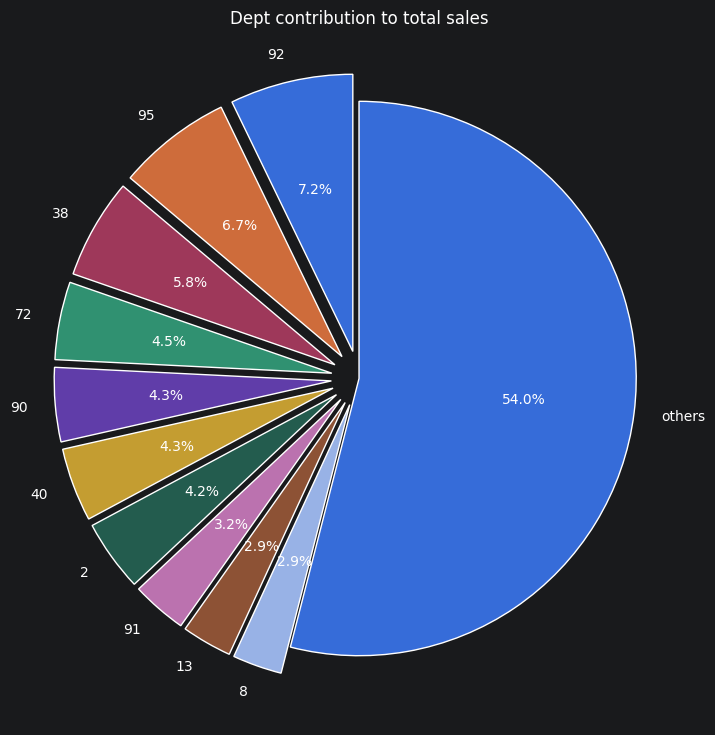

In [43]:
plt.figure(figsize=(9,9))
explode= [0.1]*10 +[0]
plt.pie(Pie_chart, labels= Pie_chart. index, autopct='%1.1f%%', explode=explode,startangle=90, wedgeprops={'edgecolor':'white','linewidth':1})
plt.title('Dept contribution to total sales')
plt.show()

In [44]:
#Department-wise variability
Dept_agg=df.groupby('Dept')['Weekly_Sales'].agg(['sum', 'mean', 'std'])
Dept_agg.head()

,sum,mean,std
Dept,,,
1,"123,638,776.54","19,213.49","15,102.37"
2,"280,611,174.43","43,607.02","25,176.76"
3,"75,892,449.95","11,793.70","12,790.99"
4,"167,146,745.58","25,974.63","13,261.14"
5,"135,607,358.61","21,368.95","19,988.23"


In [45]:
Depwise_CV= (Dept_agg['std']/Dept_agg['mean']).sort_values(ascending=False).round(2)
Depwise_CV.head()

Dept
59   2.86
99   2.63
18   1.84
56   1.56
47   1.47
dtype: float64

In [46]:
Dept_agg['CV']= Depwise_CV
Dept_agg.sort_values(by='CV',ascending=False).round(2).head()

,sum,mean,std,CV
Dept,,,,
59,"4,240,806.34",699.57,"1,997.67",2.86
99,"358,409.33",420.18,"1,104.56",2.63
18,"36,899,308.11","7,609.67","14,018.36",1.84
56,"22,511,687.68","3,838.96","5,980.73",1.56
47,"48,225.13",123.02,180.87,1.47


In [47]:
#Dept 59 is the most stable dept

### Store Type Performance

In [48]:
#Average sales by Type (A/B/C)

In [49]:
df.columns

Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Holiday',
       'Dept', 'Weekly_Sales', 'Type', 'Size'],
      dtype='object')

In [50]:
Sales_by_type=df.groupby('Type')['Weekly_Sales'].agg(['sum', 'mean', 'std'])
Sales_by_type

,sum,mean,std
Type,,,
A,"4,331,057,478.53","20,145.11","26,435.82"
B,"2,000,741,648.34","12,288.13","17,221.04"
C,"405,508,021.80","9,547.43","16,000.32"


In [51]:
Sales_dist_by_type=(Sales_by_type['sum']/total_sales)*100
Sales_dist_by_type

Type
A   64.28
B   29.70
C    6.02
Name: sum, dtype: float64

In [52]:
Sales_by_type['Type_Sales_contribution']=Sales_dist_by_type
Sales_by_type

,sum,mean,std,Type_Sales_contribution
Type,,,,
A,"4,331,057,478.53","20,145.11","26,435.82",64.28
B,"2,000,741,648.34","12,288.13","17,221.04",29.70
C,"405,508,021.80","9,547.43","16,000.32",6.02


In [53]:
#Number of stores in each Type 

In [54]:
Store_count=(df.groupby('Type')['Store'].nunique().reset_index())
Store_count.columns=['Store_Type', 'Number_of_stores']
Store_count.style.hide(axis='index')

Store_Type,Number_of_stores
A,22
B,17
C,6


### Store Size Performance

In [55]:
df.columns

Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Holiday',
       'Dept', 'Weekly_Sales', 'Type', 'Size'],
      dtype='object')

In [56]:
df.Size.nunique()

40

In [57]:
store_size_sales=df.groupby('Size')['Weekly_Sales'].sum().reset_index()
store_size_sales.sort_values(by='Size', ascending=False).head()

,Size,Weekly_Sales
39,219622,"286,517,950.36"
38,207499,"193,964,391.99"
37,206302,"189,271,508.03"
36,205863,"299,545,269.30"
35,204184,"253,857,189.97"


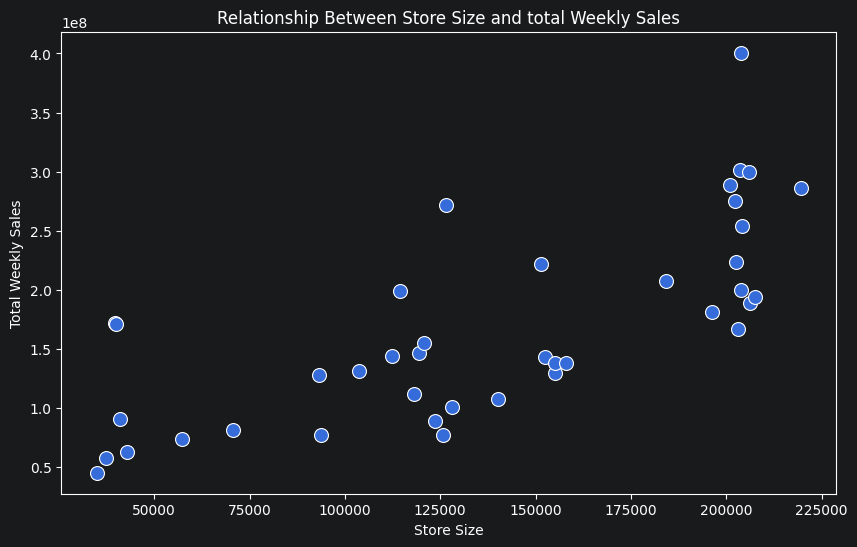

In [58]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=store_size_sales,x='Size',y='Weekly_Sales',s=100)

plt.title("Relationship Between Store Size and total Weekly Sales")
plt.xlabel("Store Size")
plt.ylabel("Total Weekly Sales")

plt.show()

In [59]:
#correlation between size and sales
corr=store_size_sales.corr()
corr

,Size,Weekly_Sales
Size,1.00,0.72
Weekly_Sales,0.72,1.00


### There is a strong positive relationship between store size and weekly sales. Larger stores generally generate higher weekly sales. But we cannot conclude that size alone determines sales. Stores arou d 200,000 sq.feet have sales ranging from 170 to 400 million. So other factors can also contribute such as location, store type, promotions, holidays, unempleyment, CPI and fuel prices.

### Time-Based Performance

In [60]:
df['Year']=df['Date'].dt.year
df['Month_name']=df['Date'].dt.month_name()
df['Month']=df['Date'].dt.month
df['Quarter']=df['Date'].dt.quarter

In [61]:
#Weekly sales
weekly_sales=df.groupby('Date')['Weekly_Sales'].sum().reset_index()
weekly_sales.head()

,Date,Weekly_Sales
0,2010-02-05,"49,750,875.98"
1,2010-02-12,"48,336,800.10"
2,2010-02-19,"48,277,902.33"
3,2010-02-26,"43,970,440.65"
4,2010-03-05,"46,872,715.16"


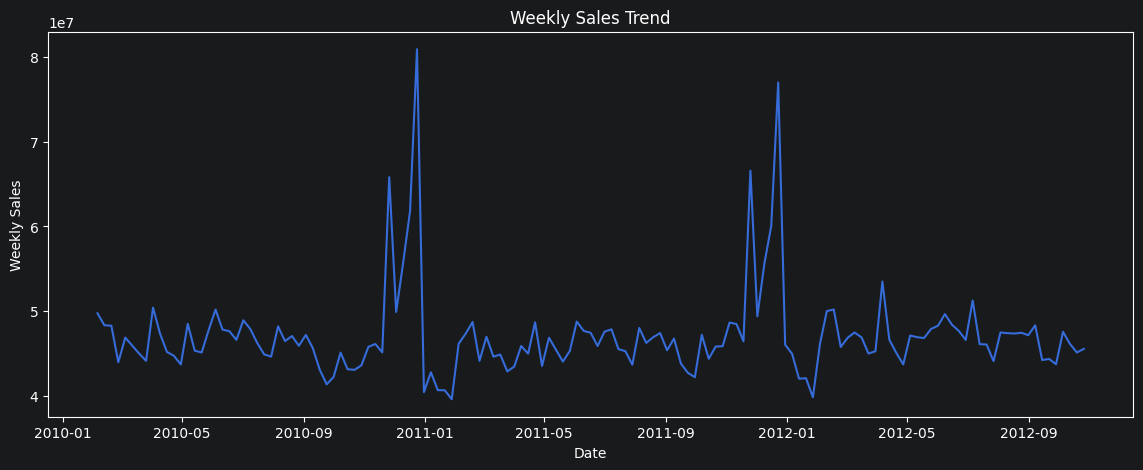

In [62]:
plt.figure(figsize=(14,5))
plt.plot(weekly_sales['Date'], weekly_sales['Weekly_Sales'])
plt.title("Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()

In [63]:
weekly_sales=weekly_sales.sort_values(by='Weekly_Sales', ascending=False)
weekly_sales

,Date,Weekly_Sales
46,2010-12-24,"80,931,586.20"
98,2011-12-23,"76,999,773.57"
94,2011-11-25,"66,593,835.85"
42,2010-11-26,"65,821,216.26"
45,2010-12-17,"61,821,317.85"
...,...,...
49,2011-01-14,"40,673,850.98"
50,2011-01-21,"40,654,860.31"
47,2010-12-31,"40,434,740.42"
103,2012-01-27,"39,835,117.15"


In [64]:
#Monthly sales trend
monthly_sales=df.groupby(['Month_name', 'Month'])['Weekly_Sales'].sum().reset_index()

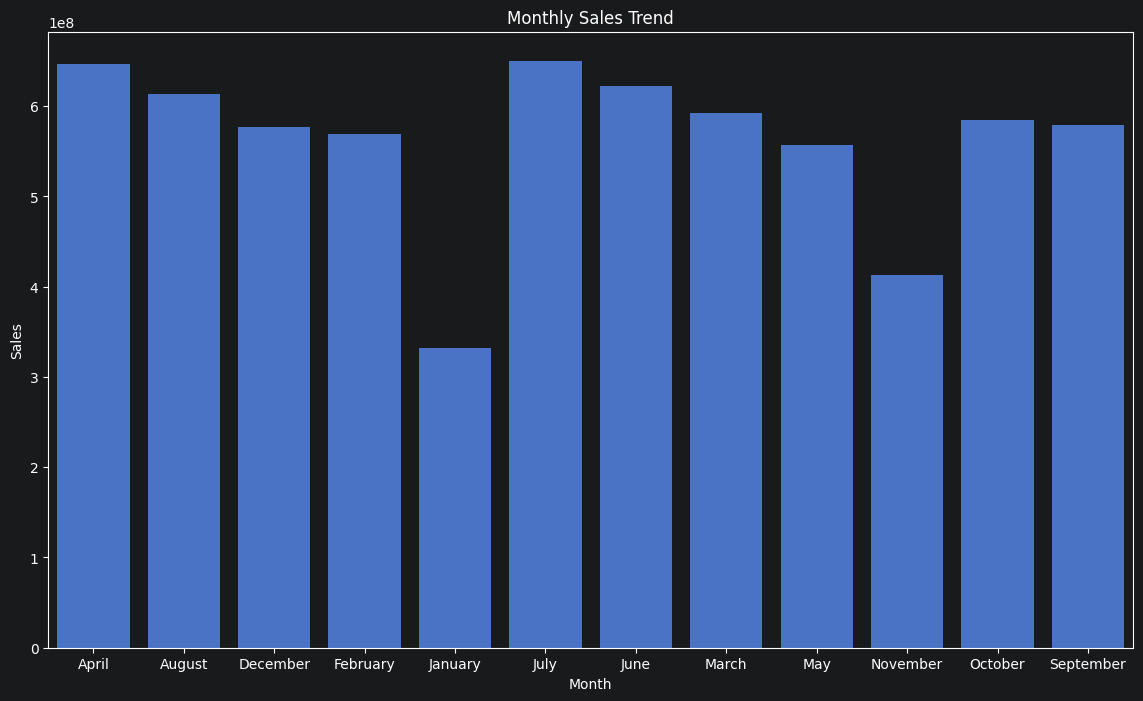

In [65]:
plt.figure(figsize=(14,8))
sns.barplot(data=monthly_sales, x='Month_name', y='Weekly_Sales')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [66]:
monthly_sales= monthly_sales.sort_values(by='Weekly_Sales', ascending=False)
monthly_sales

,Month_name,Month,Weekly_Sales
5,July,7,"650,008,941.59"
0,April,4,"646,865,790.75"
6,June,6,"622,633,477.60"
1,August,8,"613,097,865.02"
7,March,3,"592,797,392.00"
10,October,10,"584,795,416.44"
11,September,9,"578,775,125.75"
2,December,12,"576,849,089.51"
3,February,2,"568,733,872.82"
8,May,5,"557,129,755.98"


In [67]:
# Quaterly sales
quaterly_sales=df.groupby(['Year','Quarter'])['Weekly_Sales'].sum().reset_index()
quaterly_sales

,Year,Quarter,Weekly_Sales
0,2010,1,"372,259,590.46"
1,2010,2,"610,372,504.94"
2,2010,3,"597,495,910.30"
3,2010,4,"708,790,877.32"
4,2011,1,"529,398,055.54"
5,2011,2,"597,953,134.37"
6,2011,3,"639,372,043.70"
7,2011,4,"681,509,390.26"
8,2012,1,"592,475,491.44"
9,2012,2,"618,303,385.02"


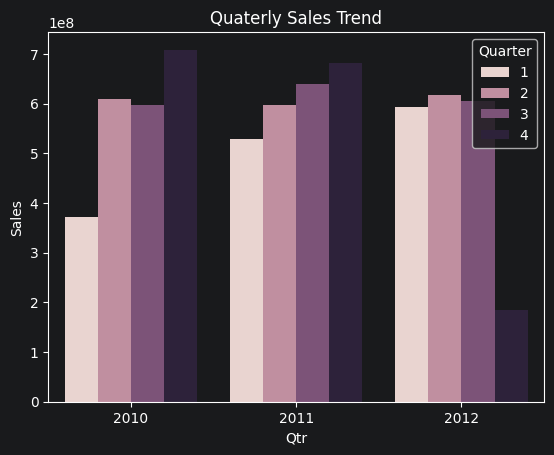

In [68]:
sns.barplot(data=quaterly_sales, x='Year', y='Weekly_Sales', hue='Quarter')
plt.title("Quaterly Sales Trend")
plt.xlabel("Qtr")
plt.ylabel("Sales")
plt.show()

In [69]:
quaterly_sales=quaterly_sales.sort_values(by='Weekly_Sales', ascending=False)
quaterly_sales

,Year,Quarter,Weekly_Sales
3,2010,4,"708,790,877.32"
7,2011,4,"681,509,390.26"
6,2011,3,"639,372,043.70"
9,2012,2,"618,303,385.02"
1,2010,2,"610,372,504.94"
10,2012,3,"605,013,978.36"
5,2011,2,"597,953,134.37"
2,2010,3,"597,495,910.30"
8,2012,1,"592,475,491.44"
4,2011,1,"529,398,055.54"


In [70]:
#Yearly trend
Yearly_sales=df.groupby('Year')['Weekly_Sales'].sum().reset_index()
Yearly_sales

,Year,Weekly_Sales
0,2010,"2,288,918,883.02"
1,2011,"2,448,232,623.87"
2,2012,"2,000,155,641.78"


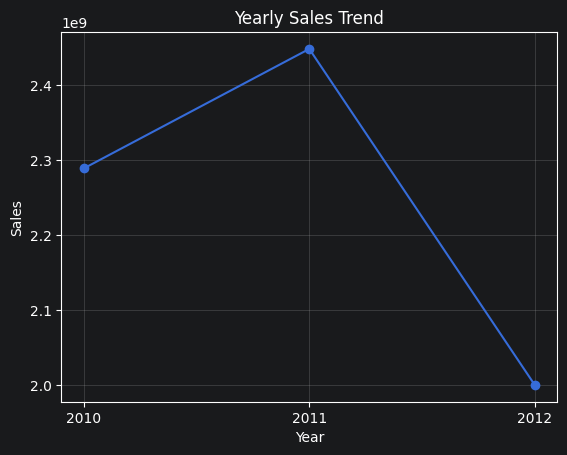

In [71]:
plt.plot(Yearly_sales['Year'],Yearly_sales['Weekly_Sales'], marker='o' )
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.xticks(Yearly_sales['Year'])
plt.grid(alpha=0.3)
plt.show()

### Holiday Performance

In [72]:
# Holiday vs non-holiday sales

In [73]:
df.columns

Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Holiday',
       'Dept', 'Weekly_Sales', 'Type', 'Size', 'Year', 'Month_name', 'Month',
       'Quarter'],
      dtype='object')

In [74]:
holiday_sales=df.groupby('Holiday')['Weekly_Sales'].sum().reset_index()
holiday_sales

,Holiday,Weekly_Sales
0,False,"6,231,999,613.52"
1,True,"505,307,535.15"


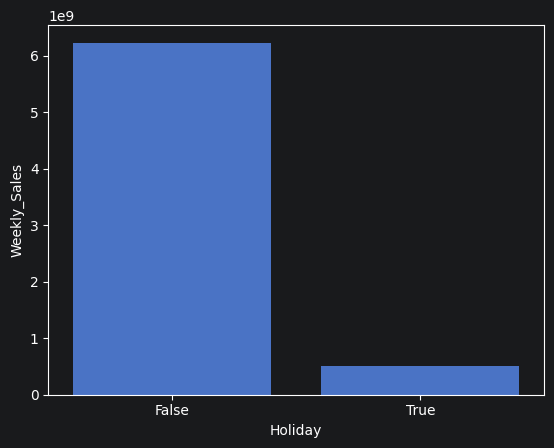

In [75]:
sns.barplot(data=holiday_sales, x=holiday_sales['Holiday'], y=holiday_sales['Weekly_Sales'])
plt.show()

In [76]:
holiday_df=df[df['Holiday']==True]

In [77]:
holiday_sales_storewise=holiday_df.groupby(['Holiday', 'Store'])['Weekly_Sales'].sum().sort_values(ascending=False).reset_index()
holiday_sales_storewise.head()

,Holiday,Store,Weekly_Sales
0,True,20,"22,491,780.85"
1,True,4,"22,431,026.24"
2,True,14,"21,205,829.98"
3,True,10,"21,138,063.24"
4,True,13,"21,130,438.06"


In [78]:
holiday_sales_deptwise=holiday_df.groupby(['Holiday', 'Dept'])['Weekly_Sales'].sum().sort_values(ascending=False).reset_index()
holiday_sales_deptwise.head()

,Holiday,Dept,Weekly_Sales
0,True,72,"40,314,400.37"
1,True,92,"35,695,397.10"
2,True,95,"29,996,233.40"
3,True,38,"25,682,245.57"
4,True,90,"21,209,128.22"


In [79]:
#Average holiday sales 
avg_holiday_sales=holiday_df.groupby('Holiday')['Weekly_Sales'].mean().reset_index()
avg_holiday_sales

,Holiday,Weekly_Sales
0,True,"17,092.57"


In [80]:
#Average non-holiday sales
non_holiday_df=df[df['Holiday']==False]

In [81]:
avg_non_holiday_sales=non_holiday_df.groupby('Holiday')['Weekly_Sales'].mean().reset_index()
avg_non_holiday_sales

,Holiday,Weekly_Sales
0,False,"15,949.96"


### Promotion Performance

In [82]:
promo_df=df[
(df['MarkDown1']>0) |
(df['MarkDown2']>0)|
(df['MarkDown3']>0)|
(df['MarkDown4']>0)|
(df['MarkDown5']>0)]

In [83]:
promo_df.head(2)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Holiday,Dept,Weekly_Sales,Type,Size,Year,Month_name,Month,Quarter
6579,1,2011-11-11,59.11,3.30,"10,382.90","6,115.67",215.07,"2,406.62","6,551.42",218.00,7.87,False,1,"18,689.54",A,151315,2011,November,11,4
6580,1,2011-11-11,59.11,3.30,"10,382.90","6,115.67",215.07,"2,406.62","6,551.42",218.00,7.87,False,2,"44,936.47",A,151315,2011,November,11,4


In [84]:
promo_sales=promo_df['Weekly_Sales'].sum()
promo_sales

np.float64(2449746112.91)

In [85]:
non_promo_df=df[
(df['MarkDown1']==0) |
(df['MarkDown2']==0)|
(df['MarkDown3']==0)|
(df['MarkDown4']==0)|
(df['MarkDown5']==0)]

In [86]:
non_promo_sales=non_promo_df['Weekly_Sales'].sum()
non_promo_sales

np.float64(5008354489.79)

In [87]:
sales_compare=pd.DataFrame({'category':['Promo','No_promo'],
                          'Sales': [promo_sales, non_promo_sales]})
sales_compare.style.hide(axis='index')

category,Sales
Promo,2449746112.910000
No_promo,5008354489.790000


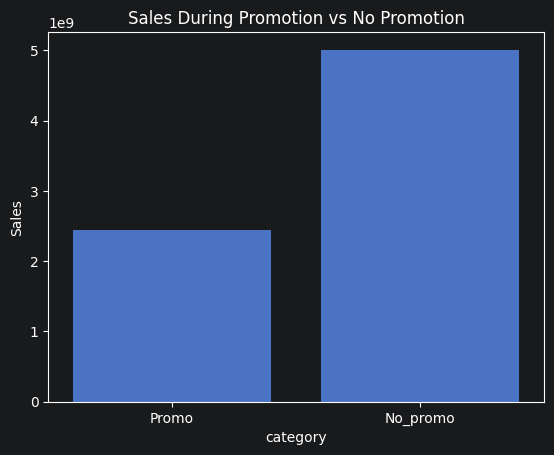

In [88]:
sns.barplot(data=sales_compare,
            x='category',
            y='Sales')

plt.title("Sales During Promotion vs No Promotion")
plt.show()

In [89]:
#Which MarkDown variable has the strongest relationship with sales?
corr=df[['Weekly_Sales','MarkDown1', 'MarkDown2','MarkDown3', 'MarkDown4', 'MarkDown5']].corr()
corr['Weekly_Sales'].sort_values(ascending=False)

Weekly_Sales   1.00
MarkDown5      0.05
MarkDown1      0.05
MarkDown3      0.04
MarkDown4      0.04
MarkDown2      0.02
Name: Weekly_Sales, dtype: float64

### the correlation with Markdown5 and 1 is very weak. This indicates that promotional discounts donot influence sales that much

In [90]:
## sales that happened during promotions
sales_during_promotions=promo_df['Weekly_Sales'].sum()
sales_during_promotions

np.float64(2449746112.91)

In [91]:
#promo impact
promo_impact=((sales_during_promotions/total_sales)*100).round()
promo_impact

np.float64(36.0)

### Around 36% total sales occurred during promotional weeks

### External Factors

In [92]:
#Temperature , Fuel Price , CPI ,Unemployment 

In [93]:
external_factor_corr=df[['Weekly_Sales',
                    'Temperature',
                    'Fuel_Price',
                    'CPI',
                    'Unemployment']].corr()
external_factor_corr['Weekly_Sales'].sort_values(ascending=False)

Weekly_Sales    1.00
Fuel_Price      0.00
Temperature    -0.00
CPI            -0.02
Unemployment   -0.03
Name: Weekly_Sales, dtype: float64

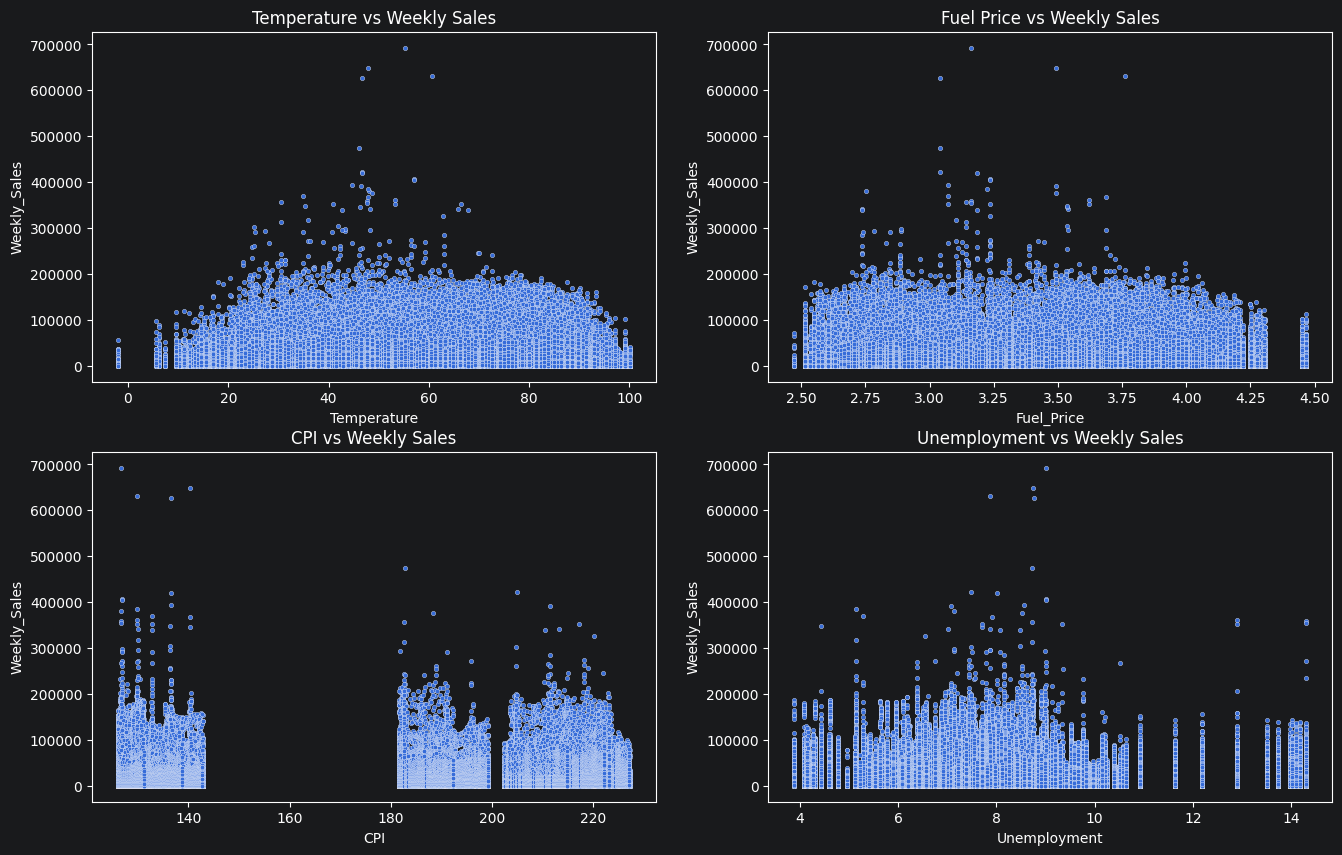

In [94]:
##Subplot
plt.figure(figsize=(16,10))
plt.subplot(2,2,1)
sns.scatterplot(data=df,
                x='Temperature',
                y='Weekly_Sales',
               s=10)
plt.title("Temperature vs Weekly Sales")

plt.subplot(2,2,2)
sns.scatterplot(data=df,
                x='Fuel_Price',
                y='Weekly_Sales',
               s=10)

plt.title("Fuel Price vs Weekly Sales")

plt.subplot(2,2,3)
sns.scatterplot(data=df,
                x='CPI',
                y='Weekly_Sales',
               s=10)
plt.title("CPI vs Weekly Sales")

plt.subplot(2,2,4)
sns.scatterplot(data=df,
                x='Unemployment',
                y='Weekly_Sales',
               s=10)
plt.title("Unemployment vs Weekly Sales")
plt.show()

### 
Temperature shows virtually no relationship.
Fuel Price has no meaningful relationship.
CPI has a negligible negative relationship.
Unemployment has a negligible negative relationship.

In [95]:
df.columns

Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Holiday',
       'Dept', 'Weekly_Sales', 'Type', 'Size', 'Year', 'Month_name', 'Month',
       'Quarter'],
      dtype='object')

In [96]:
### Saving df_final to csv
df.to_csv('df_final.csv', index=False)